In [1]:
import os
import json

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
with open("abuse_ip_info.json", mode="r", encoding="utf-8") as f:
    data = json.load(f)
len(data)

5502

In [3]:
data

{'1.117.61.18': {'data': {'data': {'abuseConfidenceScore': 100,
    'countryCode': 'CN',
    'domain': 'tencent.com',
    'hostnames': [],
    'ipAddress': '1.117.61.18',
    'ipVersion': 4,
    'isPublic': True,
    'isTor': False,
    'isWhitelisted': False,
    'isp': 'Tencent cloud computing (Beijing) Co., Ltd.',
    'lastReportedAt': '2025-06-03T00:31:11+00:00',
    'numDistinctUsers': 43,
    'totalReports': 135,
    'usageType': 'Data Center/Web Hosting/Transit'}},
  'status': 'success'},
 '1.173.128.187': {'data': {'data': {'abuseConfidenceScore': 47,
    'countryCode': 'TW',
    'domain': 'cht.com.tw',
    'hostnames': ['1-173-128-187.dynamic-ip.hinet.net'],
    'ipAddress': '1.173.128.187',
    'ipVersion': 4,
    'isPublic': True,
    'isTor': False,
    'isWhitelisted': False,
    'isp': 'Chunghwa Telecom Co.,Ltd.',
    'lastReportedAt': '2025-05-31T09:30:50+00:00',
    'numDistinctUsers': 8,
    'totalReports': 10,
    'usageType': 'Fixed Line ISP'}},
  'status': 'success'

In [4]:
data_parsed = {}

for ip, info in data.items():
    info = info["data"]["data"]
    score = info["abuseConfidenceScore"]
    reports = info["totalReports"]
    usage = info["usageType"]
    tor = info["isTor"]
    public = info["isPublic"]
    isp = info["isp"]
    country = info["countryCode"]
    domain = info["domain"]
    data_parsed[ip] = [score, reports, usage, tor, public, isp, country, domain]
df = pd.DataFrame.from_dict(data_parsed, orient="index", columns=["Score", "Reports", "Usage", "isTor", "isPublic", "ISP", "Country", "Domain"]).reset_index()
df = df.rename(columns={"index":"IP"})
df.head()

,IP,Score,Reports,Usage,isTor,isPublic,ISP,Country,Domain
0,1.117.61.18,100,135,Data Center/Web Hosting/Transit,False,True,"Tencent cloud computing (Beijing) Co., Ltd.",CN,tencent.com
1,1.173.128.187,47,10,Fixed Line ISP,False,True,"Chunghwa Telecom Co.,Ltd.",TW,cht.com.tw
2,1.176.134.250,44,11,Fixed Line ISP,False,True,LG HelloVision Corp.,KR,lghellovision.net
3,1.2.171.128,100,53,Fixed Line ISP,False,True,TOT Public Company Limited,TH,tot.co.th
4,1.2.239.128,47,7,Fixed Line ISP,False,True,TOT Public Company Limited,TH,tot.co.th


In [5]:
df[df["isTor"] == True]

,IP,Score,Reports,Usage,isTor,isPublic,ISP,Country,Domain


In [6]:
df[df["isPublic"] == False]

,IP,Score,Reports,Usage,isTor,isPublic,ISP,Country,Domain


In [7]:
df[["Score", "Reports"]].describe()

,Score,Reports
count,5502.000000,5502.000000
mean,73.832788,464.299164
std,36.389154,1751.323994
min,0.000000,0.000000
25%,45.000000,15.000000
50%,100.000000,83.000000
75%,100.000000,448.500000
max,100.000000,77243.000000


In [8]:
df["Usage"].unique()

array(['Data Center/Web Hosting/Transit', 'Fixed Line ISP', 'Commercial',
       'University/College/School', 'Mobile ISP',
       'Content Delivery Network', 'Government'], dtype=object)

In [9]:
df[df["Usage"].isin(["Government"])]

,IP,Score,Reports,Usage,isTor,isPublic,ISP,Country,Domain
3206,203.172.184.21,90,30,Government,False,True,Ministry of Education - EMISC,TH,uni.net.th


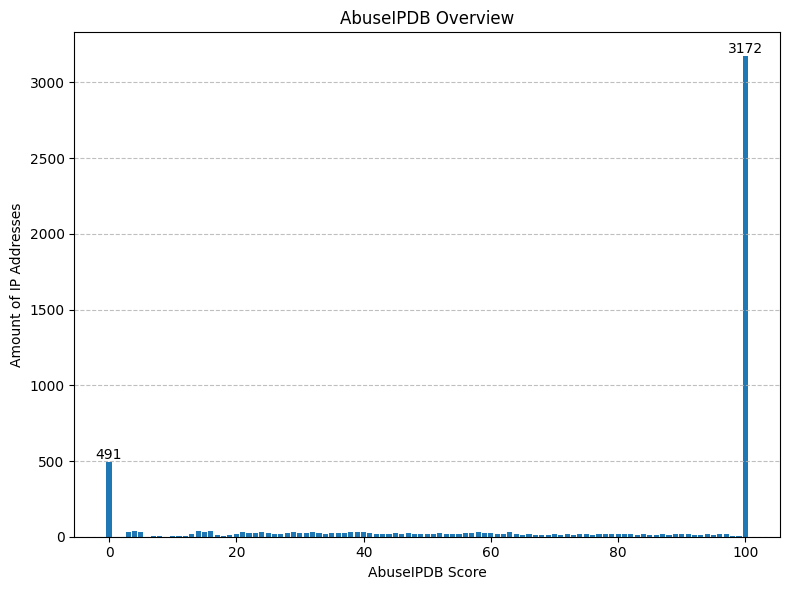

In [10]:
plt.figure(figsize=(8, 6))

p = plt.bar(df.groupby("Score")["Score"].count().index, df.groupby("Score")["Score"].count())

for bar in p:
    height = bar.get_height()
    if height > 200:
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # x position (center of bar)
            height,                             # y position (top of bar)
            f'{height:.0f}',                    # label text
            ha='center', va='bottom'            # alignment
        )

plt.title("AbuseIPDB Overview")
plt.ylabel("Amount of IP Addresses")
plt.xlabel("AbuseIPDB Score")

plt.grid(True, axis="y", linestyle="--", alpha=0.8)
plt.tight_layout()
plt.savefig("deployment_viz/4_abusescores.png", dpi=300)
plt.show()

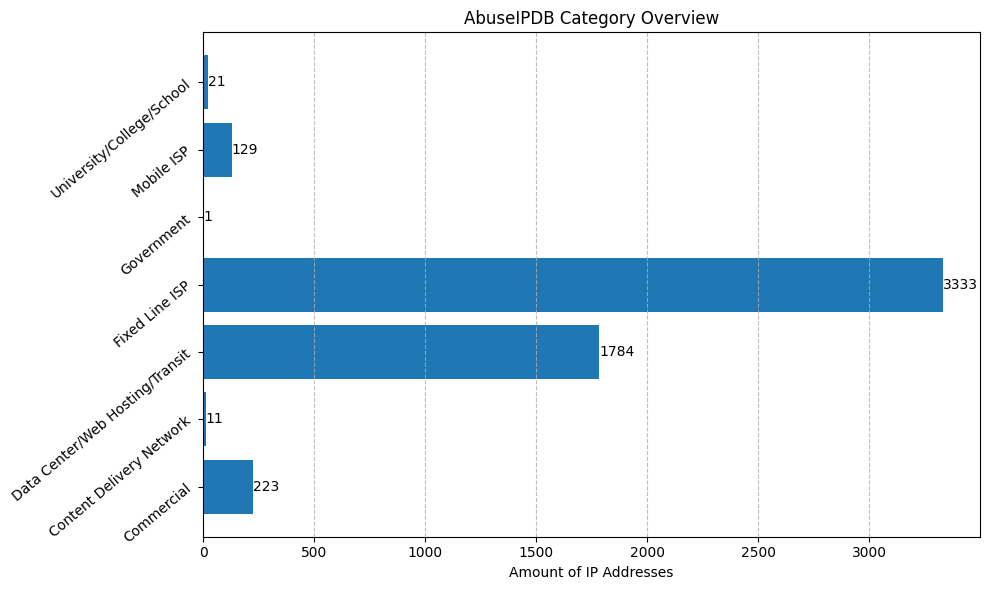

In [11]:
plt.figure(figsize=(10, 6))

p = plt.barh(df.groupby("Usage")["Score"].count().index, df.groupby("Usage")["Score"].count())

plt.bar_label(p)
plt.yticks(rotation=40)

plt.title("AbuseIPDB Category Overview")
plt.xlabel("Amount of IP Addresses")
# plt.ylabel("AbuseIDP Usage Category")

plt.grid(True, axis="x", linestyle="--", alpha=0.8)
plt.tight_layout()
plt.savefig("deployment_viz/5_abusescts.png", dpi=300)
plt.show()

In [12]:
df[df["Reports"] == 0].reset_index().head()

,index,IP,Score,Reports,Usage,isTor,isPublic,ISP,Country,Domain
0,49,101.71.220.227,0,0,Fixed Line ISP,False,True,UNICOM ZheJiang Province Network,CN,chinaunicom.cn
1,94,103.209.254.239,0,0,Fixed Line ISP,False,True,"Melbourne, AU",AU,strongtechnology.net
2,169,104.28.45.4,0,0,Data Center/Web Hosting/Transit,False,True,"Cloudflare, Inc.",DK,cloudflare.com
3,170,104.28.45.5,0,0,Data Center/Web Hosting/Transit,False,True,"Cloudflare, Inc.",DK,cloudflare.com
4,428,116.205.230.49,37,0,Data Center/Web Hosting/Transit,False,True,Huawei Public Cloud Service (Huawei Software T...,CN,huawei.com


In [13]:
df[df["Reports"] == 0].reset_index().head()["ISP"].unique()

array(['UNICOM ZheJiang Province Network', 'Melbourne, AU',
       'Cloudflare, Inc.',
       'Huawei Public Cloud Service (Huawei Software Technologies Ltd.Co)'],
      dtype=object)

In [14]:
df[df["Reports"] == 0].reset_index().to_excel("Unreported_ips.xlsx")

In [15]:
with open("greynoise_final_results.json", mode="r", encoding="utf-8") as f:
    greynoise_data = json.load(f)

gr_data = {}
for entry in greynoise_data:
    gr_data[entry["ip"]] = {key:val for key,val in entry["data"].items() if key != "ip"}

gr_df = pd.DataFrame.from_dict(gr_data, orient="index").reset_index()
gr_df = gr_df.rename(columns={"index":"IP"})
gr_df

,IP,noise,riot,classification,name,link,last_seen,message
0,101.71.220.227,True,False,suspicious,unknown,https://viz.greynoise.io/ip/101.71.220.227,2025-06-07,Success
1,103.209.254.239,True,False,malicious,unknown,https://viz.greynoise.io/ip/103.209.254.239,2025-03-21,Success
2,104.28.45.4,True,False,unknown,unknown,https://viz.greynoise.io/ip/104.28.45.4,2025-05-22,Success
3,116.205.230.49,True,False,malicious,unknown,https://viz.greynoise.io/ip/116.205.230.49,2025-04-22,Success
4,117.193.131.236,True,False,malicious,unknown,https://viz.greynoise.io/ip/117.193.131.236,2025-06-07,Success
...,...,...,...,...,...,...,...,...
85,5.24.118.87,NaN,NaN,NaN,NaN,NaN,NaN,IP not found in GreyNoise dataset
86,59.183.2.144,NaN,NaN,NaN,NaN,NaN,NaN,IP not found in GreyNoise dataset
87,66.51.112.18,NaN,NaN,NaN,NaN,NaN,NaN,IP not found in GreyNoise dataset
88,66.51.114.95,NaN,NaN,NaN,NaN,NaN,NaN,IP not found in GreyNoise dataset


In [16]:
gr_df[gr_df["classification"].isna() == True].count()

IP                38
noise              0
riot               0
classification     0
name               0
link               0
last_seen          0
message           38
dtype: int64

In [17]:
gr_df[gr_df["classification"] == "unknown"].count()

IP                23
noise             23
riot              23
classification    23
name              23
link              23
last_seen         23
message           23
dtype: int64

In [18]:
gr_df["classification"] = gr_df["classification"].fillna("Not in DB")

In [19]:
gr_df.groupby("classification")["IP"].count()

classification
Not in DB     38
malicious     25
suspicious     4
unknown       23
Name: IP, dtype: int64

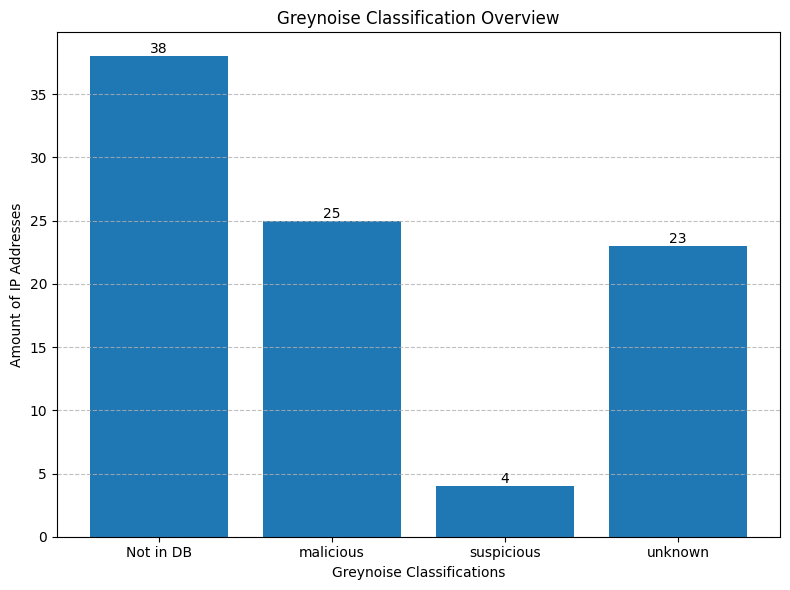

In [20]:
plt.figure(figsize=(8, 6))

p = plt.bar(gr_df.groupby("classification")["IP"].count().index, gr_df.groupby("classification")["IP"].count())

plt.bar_label(p)
# plt.yticks(rotation=40)

plt.title("Greynoise Classification Overview")
plt.ylabel("Amount of IP Addresses")
plt.xlabel("Greynoise Classifications")

plt.grid(True, axis="y", linestyle="--", alpha=0.8)
plt.tight_layout()
plt.savefig("deployment_viz/6_greynoise.png", dpi=300)
plt.show()

In [21]:
unknown_ips = gr_df[gr_df["classification"] == "Not in DB"]["IP"].to_list()
df[(df["IP"].isin(unknown_ips)) & (df["Country"] != "DK")].reset_index(drop=True).to_excel("suspicious_unkown_ips.xlsx")

In [22]:
df[df["IP"].isin(gr_df[gr_df["classification"] == "suspicious"]["IP"].to_list())].reset_index()

,index,IP,Score,Reports,Usage,isTor,isPublic,ISP,Country,Domain
0,49,101.71.220.227,0,0,Fixed Line ISP,False,True,UNICOM ZheJiang Province Network,CN,chinaunicom.cn
1,1522,146.70.102.14,12,0,Data Center/Web Hosting/Transit,False,True,M247 Europe - Dubai Infrastructure,AE,m247.com
2,2529,188.211.207.245,0,0,Fixed Line ISP,False,True,Telecommunication Company of Qom,IR,tci.ir
3,3547,219.143.174.178,1,0,Commercial,False,True,CHINANET Beijing Province Network,CN,chinatelecom.cn
